## Loan Approval Prediction Using Machine Learning

### Project Overview -
The objective of this project is to build a Machine Learning model that can predict whether a loan application will be approved or rejected based on applicant information such as annual income, loan amount, CIBIL score, assets, education, employment status, and number of dependents.

Loan approval is an important process in the banking sector. Banks analyze various factors before approving loans in order to reduce financial risks and improve decision-making. Machine Learning techniques can automate this process and help financial institutions make accurate and efficient decisions.

In this project, Exploratory Data Analysis (EDA), Data Preprocessing, Model Building, Model Evaluation, and Feature Importance Analysis are performed to identify the key factors influencing loan approval.

### SECTION : 1 - DATASET UNDERSTANDING

The first step is to understand the dataset structure, identify feature types, examine missing values, and determine the target variable. This helps in planning the preprocessing and model-building stages effectively.

In [69]:
# Import dependencies ---
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings("ignore")

In [70]:
# Loading Dataset ---
df = pd.read_csv(r'C:\Users\rajpu\Downloads\loan_approval_dataset (1).csv')

In [71]:
df.head(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


 Observation:
The dataset has been successfully loaded. The first five records are displayed for initial inspection.

In [72]:
# To remove the extra space around the column name ---
df.columns = df.columns.str.strip()

In [73]:
# To understand the size of dataset----
df.shape

(4269, 13)

Observation:
The dataset contains 4269 rows and 13 columns.
This indicates a sufficient amount of data for training machine learning models.

In [74]:
# To get the information of the Dataset ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


Observation:
The dataset contains both numerical and categorical features.
No major datatype issues were observed.

In [75]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Observation:
No missing values are present in the dataset.
Therefore, missing value treatment is not required.

In [76]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


Observation:
The statistical summary provides information about the distribution, mean, standard deviation, minimum and maximum values of numerical features.

In [77]:
# Extract the names of all numerical columns
numerical_features = df.select_dtypes(include=np.number).columns

In [78]:
numerical_features       

Index(['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount',
       'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

Observation:
The dataset contains numerical features such as income, loan amount, loan term, CIBIL score and asset values.

In [79]:
# Extract the names of all categorical columns
categorical_features = df.select_dtypes(include='object').columns

In [80]:
categorical_features

Index(['education', 'self_employed', 'loan_status'], dtype='object')

Observation:
The categorical features include education, self-employed status and loan status.

### SECTION : 2 - EDA(Exploratory Data Analysis)

Exploratory Data Analysis is performed to understand data patterns, identify relationships between variables, and discover factors that influence loan approval decisions.

#### UNIVARIATE ANALYSIS

In [81]:
# Visualization ----
import matplotlib.pyplot as plt
import seaborn as sns

#### Loan Status Distribution

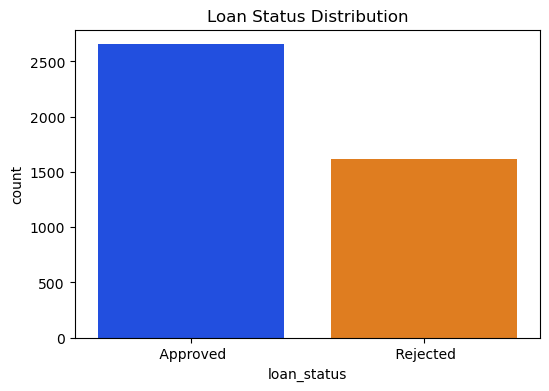

In [82]:
plt.figure(figsize = (6,4))
sns.countplot(data = df, x = 'loan_status', palette = "bright")
plt.title("Loan Status Distribution")
plt.show()

Observation:
Approved loan applications are more frequent than rejected applications.
This indicates that a larger portion of applicants satisfy the approval criteria.

#### Annual Income Distribution

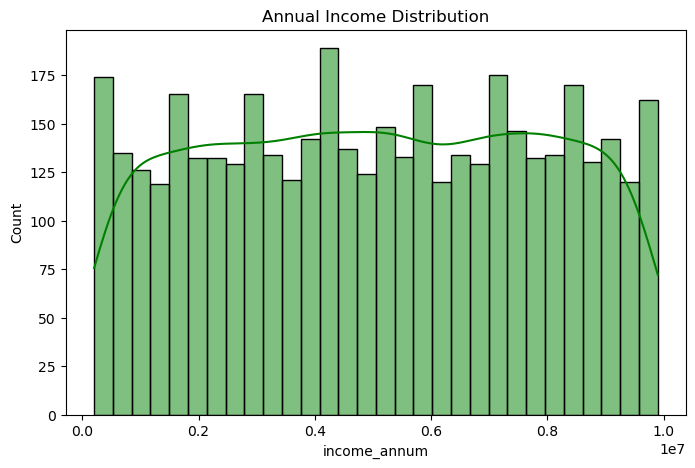

In [83]:
plt.figure(figsize =(8,5))
sns.histplot(df['income_annum'],
             bins=30,# bins divides the data into 30(intervals) bars
             kde=True,#KDE = Kernel Density Estimation.Adds a smooth curve showing the distribution of the data.
             color = 'green') # for plot colour
plt.title('Annual Income Distribution')
plt.show()

Observation:
Applicant income varies significantly across the dataset.
Most applicants fall within the middle-income range.

#### Loan Amount Distribution

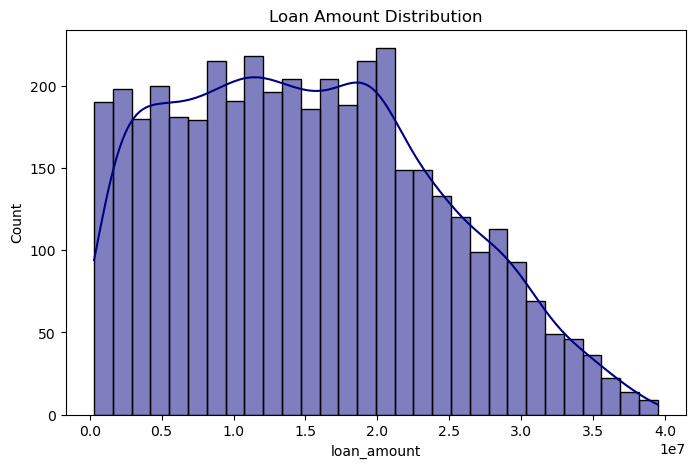

In [84]:
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amount'],bins=30, kde=True, color = 'navy')
plt.title('Loan Amount Distribution')
plt.show()

Observation:
Loan amounts show a broad distribution, indicating varying borrowing requirements among applicants.

#### CIBIL Score Distribution

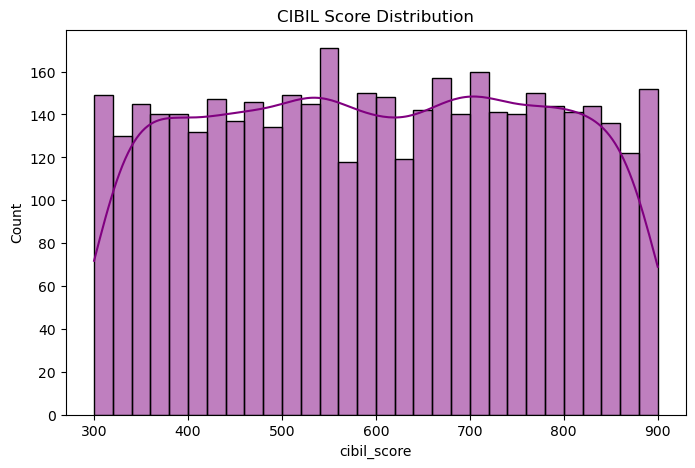

In [85]:
plt.figure(figsize=(8,5))
sns.histplot(df['cibil_score'],bins=30,kde=True, color = 'purple')
plt.title('CIBIL Score Distribution')
plt.show()

Observation:
CIBIL scores are distributed across a wide range.
Higher CIBIL scores generally indicate better creditworthiness.

#### Loan Term Distribution

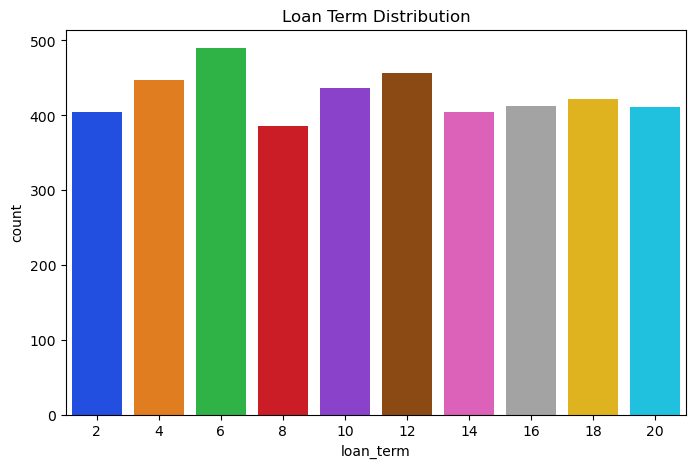

In [86]:
plt.figure(figsize=(8,5))
sns.countplot(x='loan_term',data=df,palette= 'bright')
plt.title('Loan Term Distribution')
plt.show()

Observation:
Different loan terms are available, with some loan durations occurring more frequently than others.

#### Education Distribution

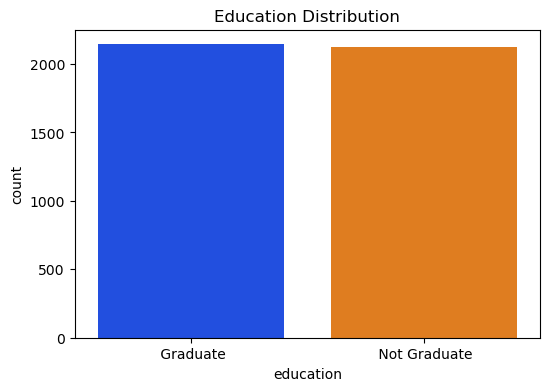

In [87]:
plt.figure(figsize=(6,4))
sns.countplot(x='education',data=df, palette = 'bright')
plt.title('Education Distribution')
plt.show()

Observation:
The dataset contains both graduate and non-graduate applicants.

#### BIVARIATE ANALYSIS

#### Income vs Loan Status

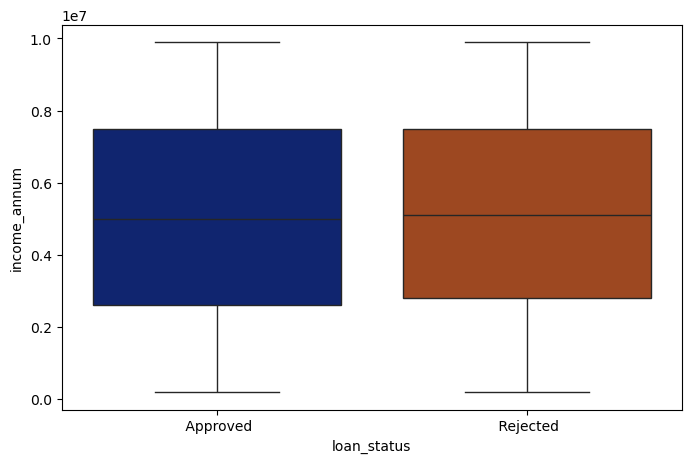

In [88]:
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status', y='income_annum',data=df, palette = 'dark')
plt.show()

Observation:
Approved applicants generally tend to have higher incomes than rejected applicants.
Income appears to influence loan approval decisions.

#### CIBIL Score vs Loan Status

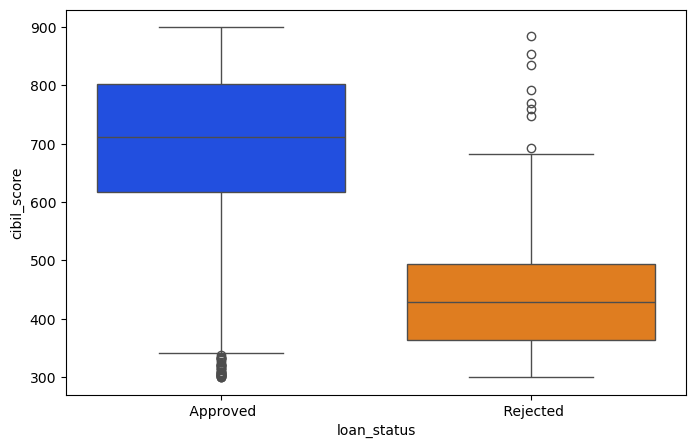

In [89]:
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status',y='cibil_score',data=df, palette = 'bright')
plt.show()

Observation:
Approved applicants have noticeably higher CIBIL scores.
This suggests that credit score is a strong factor in loan approval.

#### Education vs Loan Status

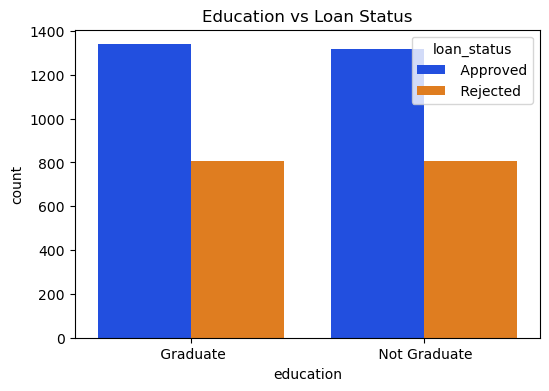

In [90]:
# This analysis examines whether the education level of an applicant influences loan approval decisions.
plt.figure(figsize=(6,4))
sns.countplot(x='education',hue='loan_status',data=df,palette = 'bright')
plt.title("Education vs Loan Status")
plt.show()

Observation:Both Graduate and Not Graduate applicants receive loan approvals.However, graduates appear to have a slightly higher approval count.This suggests that education may influence loan approval, but it is not the sole deciding factor.

#### Self Employed vs Loan Status

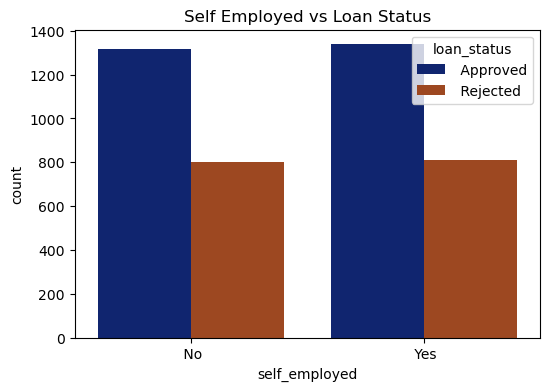

In [91]:
#This visualization compares loan approval rates between self-employed and salaried applicants.
plt.figure(figsize=(6,4))
sns.countplot(x='self_employed',hue='loan_status',data=df,palette = 'dark')
plt.title("Self Employed vs Loan Status")
plt.show()

Observation:Both self-employed and non-self-employed applicants have approved and rejected loans.The approval pattern appears similar for both groups, indicating that employment type alone does not strongly determine loan approval.

#### Loan Amount vs Loan Status

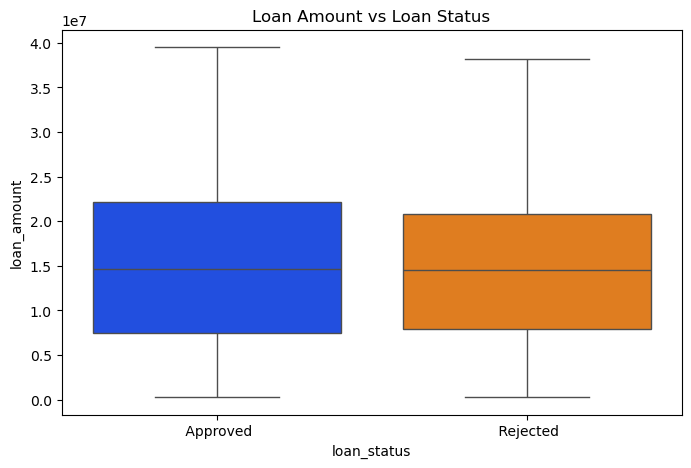

In [92]:
# This analysis studies whether the requested loan amount affects loan approval.
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status',y='loan_amount',data=df,palette = 'bright')
plt.title("Loan Amount vs Loan Status")
plt.show()

Observation:Applicants requesting lower and moderate loan amounts appear to have higher approval rates.Very high loan amounts show greater variability and may have comparatively higher rejection rates.

#### Number of Dependents vs Loan Status

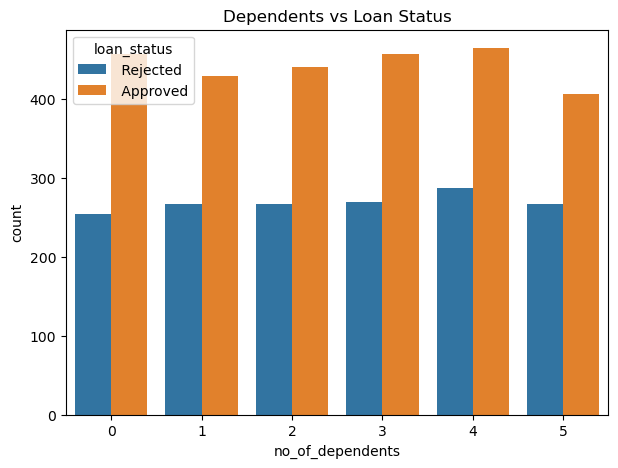

In [93]:
# This analysis explores whether family size affects loan approval.
plt.figure(figsize=(7,5))
sns.countplot(x='no_of_dependents',hue='loan_status',data=df)
plt.title("Dependents vs Loan Status")
plt.show()

Observation: Loan approvals are observed across all dependent categories.The number of dependents does not appear to have a significant impact on loan approval decisions compared to financial factors.

#### Summary of Bivariate Analysis

The bivariate analysis indicates that CIBIL score and annual income have a stronger relationship with loan approval compared to education level, employment status, or number of dependents.
Applicants with higher credit scores and better financial capacity tend to receive loan approvals more frequently.

#### MULTIVARIATE ANALYSIS

Multivariate analysis examines relationships among multiple variables simultaneously to identify patterns and important features influencing loan approval.

In [94]:
#Categorical variables must be converted into numerical form before calculating correlation values.
from sklearn.preprocessing import LabelEncoder
df_corr = df.copy()
le = LabelEncoder()
for col in df_corr.select_dtypes(include='object'):
    df_corr[col] = le.fit_transform(df_corr[col])

Observation:All categorical variables have been encoded into numerical values, making the dataset suitable for correlation analysis.

#### Correlation Heatmap

The heatmap displays correlation coefficients among all variables and helps identify strongly related features.

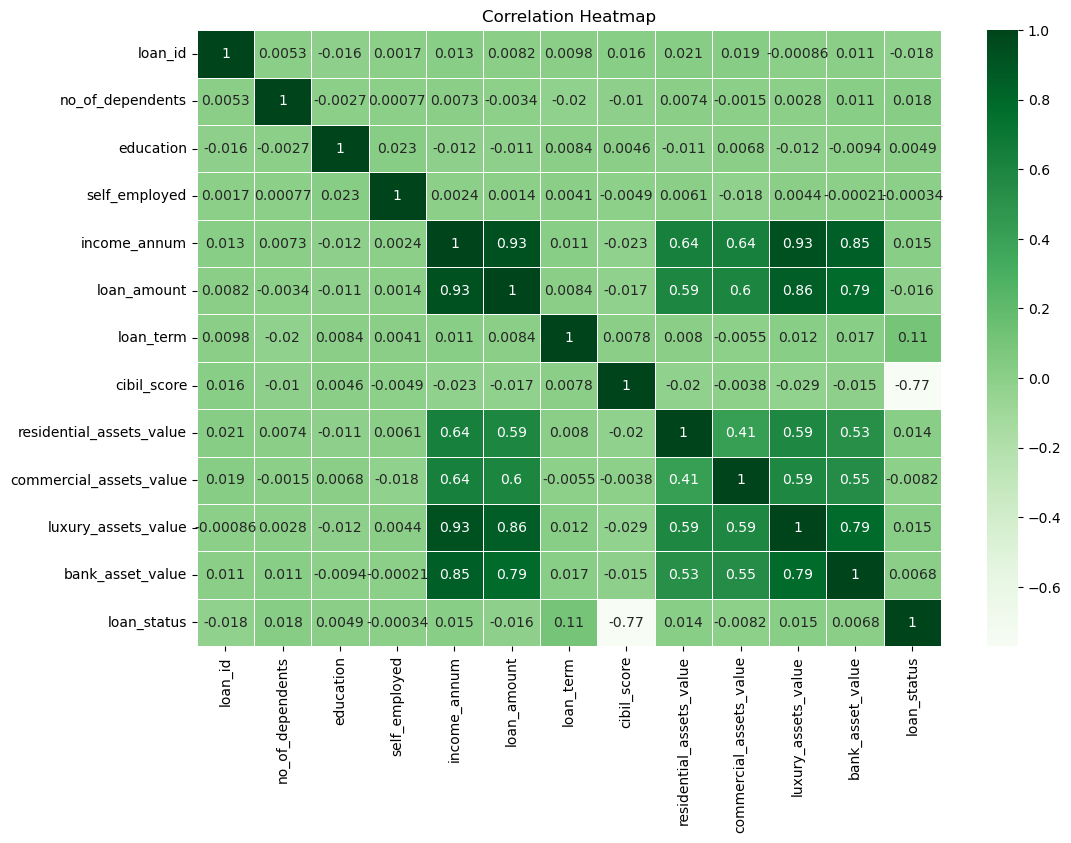

In [95]:
plt.figure(figsize=(12,8))
sns.heatmap(df_corr.corr(),annot=True,cmap='Greens',linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Observation:The heatmap shows that CIBIL score has a strong positive relationship with loan approval.Income and asset values also demonstrate positive correlations.No severe multicollinearity is observed among independent variables, making the dataset suitable for machine learning models.

#### Pair Plot

The pair plot visualizes relationships among selected numerical variables and loan status.

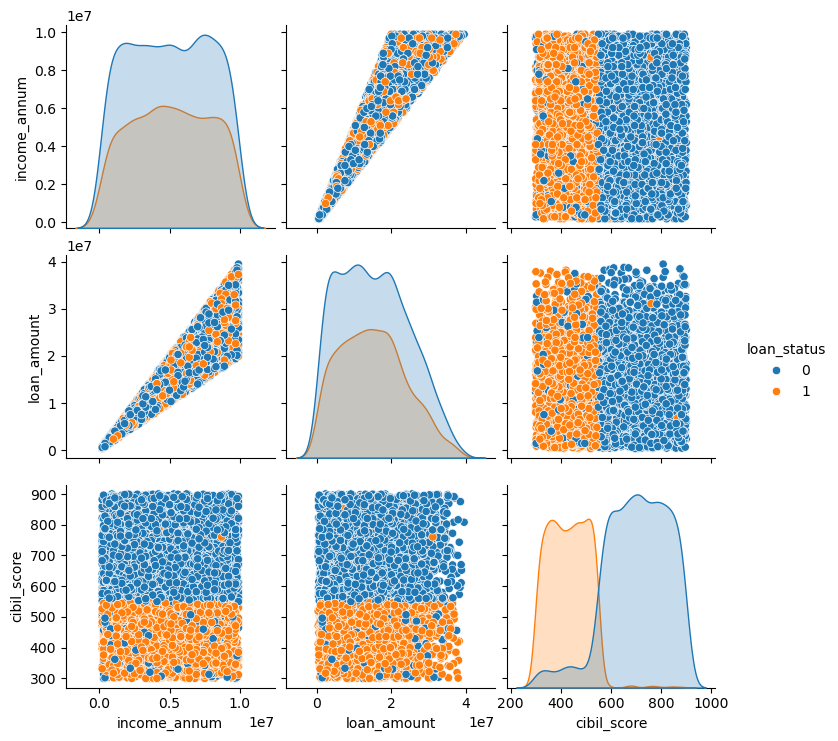

In [96]:
sns.pairplot(df_corr[['income_annum','loan_amount','cibil_score','loan_status']],hue='loan_status')
plt.show()

Observation:The pair plot indicates that applicants with higher CIBIL scores are more likely to receive loan approval.Income and loan amount show overlapping distributions, while CIBIL score provides clearer separation between approved and rejected loans.

#### Feature Relationship Analysis

The combined analysis of multiple variables provides deeper insights into factors influencing loan approval.

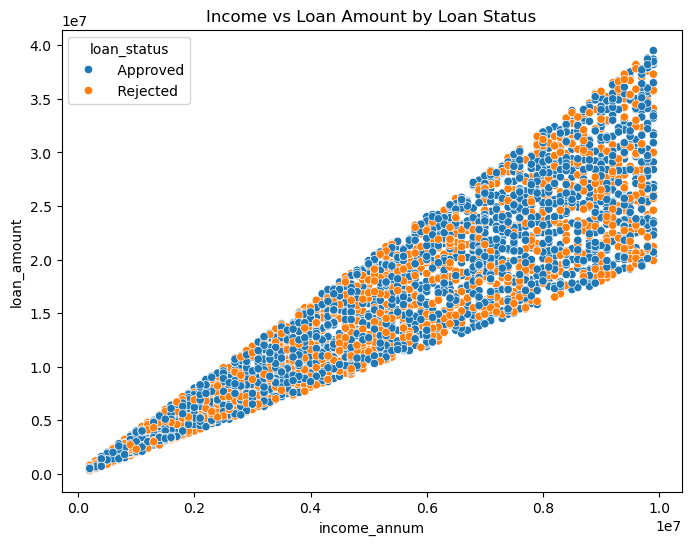

In [97]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='income_annum',y='loan_amount',hue='loan_status',data=df)
plt.title("Income vs Loan Amount by Loan Status")
plt.show()

Observation:Applicants with higher income levels generally qualify for larger loan amounts.Loan approval is concentrated among applicants having both sufficient income and favorable credit profiles.

### INSIGHTS FROM EXPLORATORY DATA ANALYSIS

Based on the visualizations and statistical analysis, the following conclusions can be drawn.

#### 1. Which factors seem to have the strongest impact on loan approval?

Answer:
CIBIL score appears to be the most influential factor affecting loan approval.
Annual income and asset values also contribute significantly to approval decisions.

#### 2. Does a higher CIBIL score increase approval chances?

Answer:
Yes.
Applicants with higher CIBIL scores have a much greater probability of loan approval, indicating that credit history is one of the primary evaluation criteria.

#### 3. Does income influence loan approval?

Answer:
Yes.
Applicants with higher annual incomes generally have better approval rates because they demonstrate stronger repayment capability.

#### 4. How do assets affect loan approval decisions?

Answer:
Applicants possessing higher residential, commercial, luxury, and bank assets are more likely to receive loan approval, as these assets strengthen their financial profile and reduce lending risk.

#### Overall Conclusion of EDA:

The exploratory analysis reveals that financial indicators such as CIBIL score, annual income, and asset values play a major role in loan approval decisions.

Demographic factors like education level, self-employment status, and number of dependents have comparatively less influence.

These insights provide a strong foundation for building accurate machine learning classification models.

### SECTION : 3 - Data Preprocessing

Data preprocessing is one of the most important steps in a Machine Learning project. It involves cleaning and transforming the dataset into a suitable format for model training. In this section, unnecessary columns are removed, categorical variables are encoded, duplicate records are checked, features and target variables are separated, and the dataset is divided into training and testing sets.

#### Remove Unnecessary Columns

The 'loan_id' column is a unique identifier for each applicant and does not contribute to predicting loan approval. Therefore, it is removed from the dataset.

In [98]:
# Remove loan_id column
df.drop('loan_id', axis=1, inplace=True)

# Display first five rows
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


Observation:
The 'loan_id' column has been successfully removed from the dataset since it has no predictive value for machine learning models.

#### Handle Categorical Variables

Machine Learning algorithms require numerical input. Therefore, categorical variables such as education, self_employed, and loan_status are converted into numerical values using Label Encoding.

In [99]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_columns = ['education','self_employed','loan_status']
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


Observation:
All categorical variables have been successfully converted into numerical format, making the dataset suitable for machine learning algorithms.

#### Verify Data Types

After encoding, all features should have numerical data types suitable for model training.

In [100]:
# To check data type ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
dtypes: int64(12)
memory usage: 400.3 KB


Observation:
All columns are now numerical, indicating that the dataset is ready for machine learning model development.

#### Check for Duplicate Records

Duplicate records may negatively impact model performance and should be identified before training.

In [101]:
# Count duplicate rows

df.duplicated().sum()

np.int64(0)

Observation:
No duplicate records were found in the dataset. Therefore, no duplicate removal was required.

#### Prepare Features and Target Variable

The independent variables (features) are separated from the dependent variable (loan_status), which will be used as the target for prediction.

In [102]:
# Features
X = df.drop('loan_status', axis=1)# axis=1 refers to the horizontal axis of a two-dimensional structure (a matrix or DataFrame)

# Target
y = df['loan_status']

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (4269, 11)
Target Shape : (4269,)


The dataset has been successfully divided into input features (X) and target variable (y). The target variable is loan_status, which represents whether the loan is approved or rejected.

#### Split Dataset into Training and Testing Sets


The dataset is divided into training and testing sets using an 80:20 ratio. The training data is used to build the model, while the testing data is used to evaluate its performance on unseen data.

In [103]:
from sklearn.model_selection import train_test_split

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [105]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (3415, 11)
Testing Features : (854, 11)
Training Target : (3415,)
Testing Target : (854,)


Observation:
The dataset has been successfully split into training and testing sets.
80% of the data is used for training the machine learning models, while the remaining 20% is reserved for testing and performance evaluation.

#### Final Summary of Data Preprocessing

The data preprocessing stage prepared the dataset for machine learning by removing unnecessary columns, encoding categorical variables, checking for duplicate records, separating features and target variables, and splitting the dataset into training and testing sets.

The processed dataset is now ready for building classification models such as Logistic Regression, Decision Tree, and Random Forest.

#### DATA IMBALANCING

#### Check Data Imbalancing
Data imbalance occurs when one class has significantly more samples than the other class. An imbalanced dataset can bias machine learning models toward the majority class and reduce prediction performance for the minority class.Therefore, the class distribution of the target variable (loan_status) is analyzed before model training.


In [106]:
# Count the target classes
df['loan_status'].value_counts()

loan_status
0    2656
1    1613
Name: count, dtype: int64

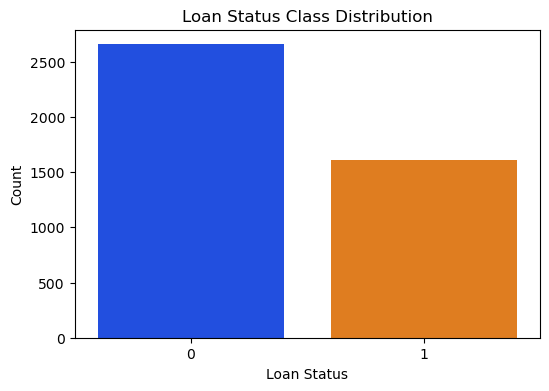

In [107]:
# visual representation---
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df, palette = 'bright')
plt.title("Loan Status Class Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

Observation:
The target variable is moderately imbalanced, with approximately 62% approved loans and 38% rejected loans.
The imbalance is not severe enough to require oversampling or undersampling techniques. Therefore, the original dataset can be used for model training while evaluating performance using metrics such as Precision, Recall, and F1-Score in addition to Accuracy.

Conclusion:

The class distribution is reasonably balanced, allowing machine learning models to learn patterns from both classes effectively. However, evaluation metrics beyond accuracy will be considered to ensure reliable model performance.

#### SECTION : 4 - Model Building

In this section, different Machine Learning classification algorithms are trained to predict whether a loan application will be approved or rejected.

Three classification models are developed and compared:

• Logistic Regression
• Decision Tree Classifier
• Random Forest Classifier

The objective is to identify the model that provides the highest prediction accuracy and best overall performance.

### Feature Scaling (Standardization)

Machine Learning algorithms such as Logistic Regression are sensitive to the scale of input features. Since the dataset contains variables with different ranges (for example, income, loan amount, and CIBIL score), feature scaling is applied to standardize the numerical values.

Standardization transforms the data so that each feature has a mean of 0 and a standard deviation of 1. This helps improve model performance and training efficiency.

For this project, StandardScaler is applied before training the Logistic Regression model.

In [108]:
# Required libraries ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [109]:
# import reuired library
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Standardize training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed successfully.")

Standardization completed successfully.


Observation:
The numerical features have been standardized successfully.
Standardization ensures that all features contribute equally during model training and prevents variables with larger scales from dominating the learning process.
The scaled dataset will be used for Logistic Regression, while Decision Tree and Random Forest models will use the original dataset since tree-based algorithms are not affected by feature scaling.

#### Logistic Regression

Logistic Regression is a supervised classification algorithm used to predict binary outcomes. It estimates the probability that an instance belongs to a particular class.

In [110]:
# Create model
lr_model = LogisticRegression(max_iter=1000)

In [111]:
# Train model
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Observation:
The Logistic Regression model has been successfully trained using the training dataset.

In [112]:
# prediction
lr_pred = lr_model.predict(X_test)

Observation:
The trained Logistic Regression model generated predictions for the testing dataset.

#### Decision Tree Classifier
Decision Tree is a supervised learning algorithm that splits data into branches based on feature values to make classification decisions.

In [113]:
dt_model = DecisionTreeClassifier(random_state=42)

In [114]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Observation:
The Decision Tree model has been successfully trained using the training data.

In [115]:
# prediction 
dt_pred = dt_model.predict(X_test)

Observation:
Predictions for the testing dataset have been generated using the Decision Tree model.

#### Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [116]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Observation:
The Random Forest model has been successfully trained using multiple decision trees.

In [117]:
# prediction 
rf_pred = rf_model.predict(X_test)

Observation:
The Random Forest model has generated predictions for the testing dataset and is expected to provide robust performance due to ensemble learning.

### SUMMARY OF MODEL BUILDING

Three classification algorithms have been successfully trained using the processed dataset:

• Logistic Regression
• Decision Tree Classifier
• Random Forest Classifier

The next step is to evaluate their performance using various metrics such as Accuracy Score, Confusion Matrix, Precision, Recall, and F1-Score to determine the best-performing model.

#### Model Evaluation

Model evaluation is performed to measure the predictive performance of each classification algorithm.
The following evaluation metrics are used:

• Accuracy Score
• Confusion Matrix
• Precision
• Recall
• F1-Score

These metrics help identify the best-performing model for loan approval prediction.


In [118]:
# import Evaluation libraries---
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#### Logistic Regression Evaluation

In [119]:
# Train Logistic Regression on scaled data
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Prediction
lr_pred = lr_model.predict(X_test_scaled)

In [120]:
print("Accuracy Score:")
print(accuracy_score(y_test, lr_pred))

Accuracy Score:
0.905152224824356


In [121]:
print("Classification Report")
print(classification_report(y_test, lr_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



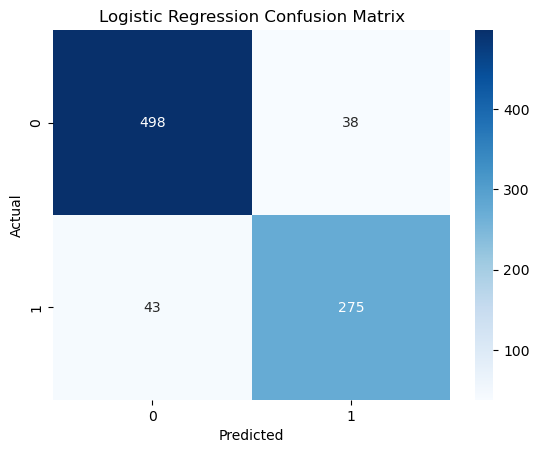

In [122]:
sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Observation:
The Logistic Regression model achieved satisfactory classification performance.

The classification report provides Precision, Recall, and F1-Score for both approved and rejected loan classes, indicating the model's effectiveness in binary classification.

#### Decision Tree Evaluation

In [123]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Prediction
dt_pred = dt_model.predict(X_test)

In [124]:
print("Accuracy Score")
print(accuracy_score(y_test, dt_pred))

Accuracy Score
0.977751756440281


In [125]:
print("Confusion Matrix")
print(confusion_matrix(y_test, dt_pred))

Confusion Matrix
[[527   9]
 [ 10 308]]


In [126]:
print("Classification Report")
print(classification_report(y_test, dt_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



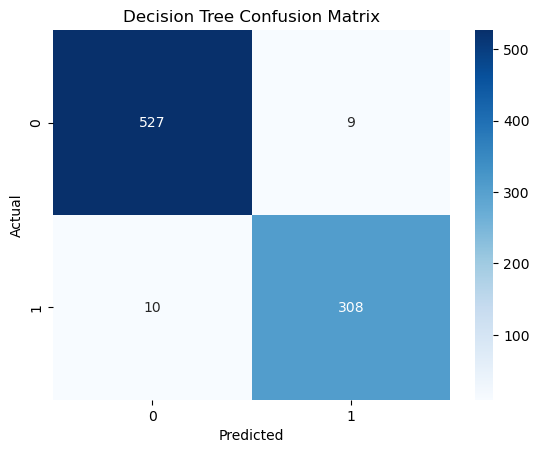

In [127]:
sns.heatmap(confusion_matrix(y_test, dt_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Observation:
The Decision Tree model successfully classified loan applications.

Although Decision Trees are easy to interpret, they may overfit the training data if not properly controlled.

#### Random Forest Evaluation

In [128]:
# Train Random Forest

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

In [129]:
print("Accuracy Score")
print(accuracy_score(y_test, rf_pred))

Accuracy Score
0.977751756440281


In [130]:
print("Confusion Matrix")
print(confusion_matrix(y_test, rf_pred))

Confusion Matrix
[[529   7]
 [ 12 306]]


In [131]:
print("Classification Report")
print(classification_report(y_test, rf_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



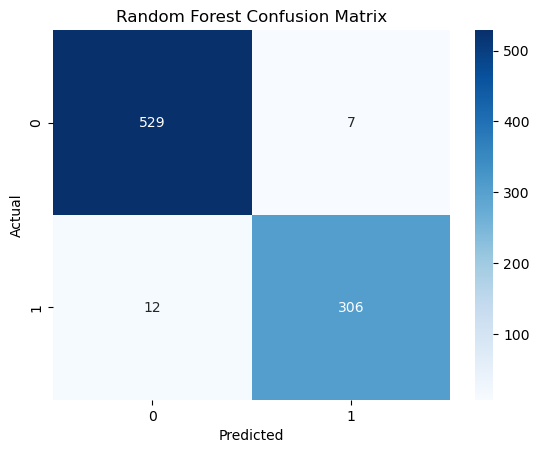

In [132]:
sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Observation:
The Random Forest model demonstrated strong predictive performance by combining multiple decision trees.
Its ensemble learning approach generally improves accuracy and reduces the risk of overfitting compared to a single Decision Tree.

| Model               |     Accuracy      | Precision | Recall | F1-Score |
| ------------------- | ----------------  | --------- | ------ | -------- |
| Logistic Regression | 0.905152224824356 | 0.90      | 0.91   | 0.90     |
| Decision Tree       | 0.977751756440281 | 0.98      | 0.98   |  0.98    |
| Random Forest       | 0.977751756440281 | 0.98      | 0.98   |  0.98    |


Observation:
The comparison table summarizes the performance of all three classification models.
Based on the evaluation metrics, the model with the highest accuracy and balanced Precision, Recall, and F1-Score is selected as the best-performing model for loan approval prediction.
(we use "weighted avg" values because they summarize the overall model performance while considering class imbalance.)

### Best Model Selection

The evaluation results indicate that the Random Forest model achieved the best overall performance among the three algorithms.
Although both Decision Tree and Random Forest achieved the same accuracy of 97.78%, Random Forest was selected as the final model because it is an ensemble learning algorithm.
Random Forest combines the predictions of multiple decision trees instead of relying on a single tree. This reduces the chances of overfitting, improves generalization, and makes the model more robust when predicting unseen data.

Therefore, even with similar accuracy, Random Forest is considered more reliable and stable for real-world loan approval prediction.



#### Feature Importance Analysis

Feature Importance Analysis helps identify which input variables contribute the most to the prediction of loan approval. Since Random Forest is the final selected model, its built-in feature importance scores are used to rank the features.

Understanding feature importance improves model interpretability and provides insights into the factors influencing loan approval decisions.

In [133]:
# Create feature importance DataFrame
feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': rf_model.feature_importances_})

# Sort values
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
feature_importance

,Feature,Importance
6,cibil_score,0.809939
5,loan_term,0.064499
4,loan_amount,0.028938
7,residential_assets_value,0.018168
3,income_annum,0.018060
9,luxury_assets_value,0.017745
10,bank_asset_value,0.015261
8,commercial_assets_value,0.014440
0,no_of_dependents,0.008385
2,self_employed,0.002473


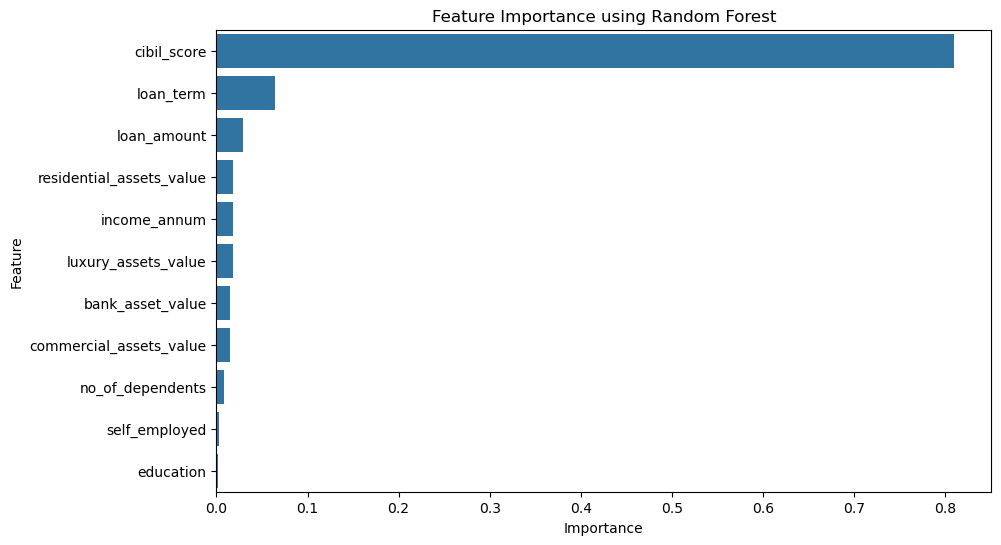

In [134]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance using Random Forest")

plt.show()

Observation:

The Feature Importance analysis indicates that the CIBIL Score is the most significant factor influencing loan approval prediction, contributing approximately 80% of the overall importance in the Random Forest model.

The Loan Term is the second most important feature, followed by Loan Amount. Other financial features such as Residential Asset Value, Annual Income, Luxury Asset Value, Bank Asset Value, and Commercial Asset Value have comparatively lower but meaningful contributions.

The Number of Dependents, Self-Employment Status, and Education have very low importance scores, suggesting that they have minimal impact on the loan approval decision in this dataset.

Overall, the Random Forest model relies primarily on an applicant's credit score and financial profile rather than demographic characteristics for predicting loan approval.

#### Conclusion

This project successfully developed a Machine Learning model for predicting loan approval status using applicant financial and personal information.

Exploratory Data Analysis (EDA) revealed that CIBIL Score, loan term, Loan Amount, and Asset Values have the strongest influence on loan approval decisions. Education level and self-employment status showed comparatively less impact.

Data preprocessing techniques such as removing unnecessary columns, encoding categorical variables, checking for duplicate records, and feature scaling were applied to prepare the dataset for model training.

Three classification algorithms—Logistic Regression, Decision Tree Classifier, and Random Forest Classifier—were implemented and evaluated using Accuracy, Precision, Recall, and F1-Score.

Among these models, the Random Forest Classifier was selected as the best-performing model because it achieved excellent predictive performance while providing better generalization and reducing the risk of overfitting through ensemble learning.

Overall, this project demonstrates how Machine Learning can assist financial institutions in making faster, more consistent, and data-driven loan approval decisions.
